<a href="https://colab.research.google.com/github/Deepak-Byte/FaceExpressionRecognizer/blob/main/Face_Expession_Detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
pip install tensorflow keras opencv-python matplotlib numpy

In [10]:
import zipfile            # To extract your dataset ZIP
import os                 # For handling file paths
import numpy as np        # For mathematical operations
import matplotlib.pyplot as plt  # For plotting graphs

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [11]:
import zipfile
import os

zip_path = "/content/archive.zip"   # Your zip file path
extract_path = "dataset"   # Extract location

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")


Dataset extracted successfully!


Import Libraries

In [12]:
train_dir = "/content/dataset/train"
test_dir = "/content/dataset/test"


In [13]:
img_size = (48, 48)  # Resize images
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,   # Normalize pixel values
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)



train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [14]:
model = Sequential([

    # 1st convolutional block
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,3)),
    MaxPooling2D(2,2),  # Reduce image size by half (pooling)

    # 2nd convolutional block
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # 3rd convolutional block
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Flatten feature maps into a 1D vector
    # The Flatten() layer takes this (10, 10, 64) tensor and converts it into a 1D vector of 10 * 10 * 64 = 6400 features.
    Flatten(),

    # Fully connected layer
    Dense(128, activation='relu'),
    Dropout(0.5),  # Randomly drop 50% of neurons to prevent overfitting

    # Output layer - softmax gives probability for each of 7 classes
    Dense(train_generator.num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',                   # Adam optimizer (adaptive learning rate)
    loss='categorical_crossentropy',    # Loss function for multi-class classification
    metrics=['accuracy']                # Track accuracy during training
)

# Show model summary
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,423 (1.36 MB)

 Trainable params: 356,423 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    train_generator,           # Training data
    validation_data=test_generator,  # Validation (test) data
    epochs= 5                  # Train for 20 passes through the dataset
)

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - accuracy: 0.2435 - loss: 1.8328 - val_accuracy: 0.2602 - val_loss: 1.7589
Epoch 2/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 42s 46ms/step - accuracy: 0.2643 - loss: 1.7767 - val_accuracy: 0.2953 - val_loss: 1.7130
Epoch 3/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.2824 - loss: 1.7431 - val_accuracy: 0.3277 - val_loss: 1.6716
Epoch 4/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 37s 41ms/step - accuracy: 0.3173 - loss: 1.6951 - val_accuracy: 0.4167 - val_loss: 1.5131
Epoch 5/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 38s 42ms/step - accuracy: 0.3643 - loss: 1.6097 - val_accuracy: 0.4386 - val_loss: 1.4389


In [16]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy*100:.2f}%")


225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4304 - loss: 1.4538
Test Accuracy: 43.86%


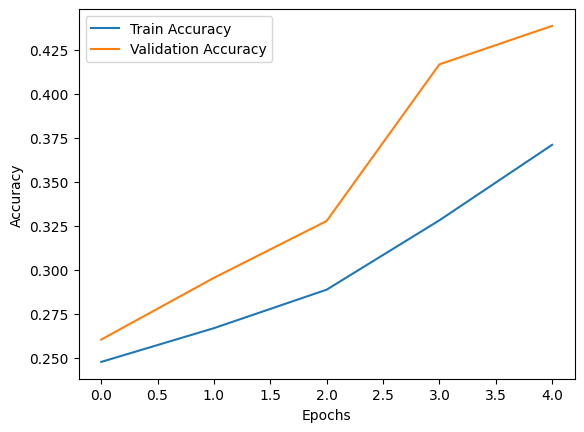

In [17]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [18]:
model.save("face_expression_model.h5")
print("Model saved successfully!")


Model saved successfully!


In [22]:
from tensorflow.keras.preprocessing import image

img_path = '/content/dataset/test/surprise/PrivateTest_10782186.jpg'  # Example image
img = image.load_img(img_path, target_size=(48,48))
img_array = image.img_to_array(img) / 255.0  # Normalize
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

pred = model.predict(img_array)
class_idx = np.argmax(pred)
class_labels = list(train_generator.class_indices.keys())
print(f"Predicted Expression: {class_labels[class_idx]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Expression: angry


In [27]:
import cv2

# Load the trained model
model = tf.keras.models.load_model("/content/face_expression_model.h5")
expression_labels = list(train_generator.class_indices.keys())

cap = cv2.VideoCapture(1)  # Capture webcam
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

while True:
    ret, frame = cap.read()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        face = frame[y:y+h, x:x+w]
        face = cv2.resize(face, (48,48))
        face = np.expand_dims(face/255.0, axis=0)
        pred = model.predict(face)
        label = expression_labels[np.argmax(pred)]

        cv2.rectangle(frame, (x,y), (x+w, y+h), (255,0,0), 2)
        cv2.putText(frame, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,0,0), 2)

    cv2.imshow('Expression Detection', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
